In [6]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from fullmodeltrain.instancepipeline import get_data_loaders2
from fullmodeltrain.finalfulltrain import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "fullmodeltrain" / "data" / "best_model_fullnn.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model = EarthquakeCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()




EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [7]:
import torch
import numpy as np
import pandas as pd

train_loader, val_loader, test_loader = get_data_loaders2()
all_predictions = []
all_targets = []
model.eval()

with torch.no_grad():
    for waveforms,magnitudes in test_loader:
        waveforms,magnitudes = waveforms.to(device), magnitudes.to(device)
        predictions = model(waveforms).squeeze(-1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())
results = pd.DataFrame({
    "true_magnitude": np.array(all_targets),
    "predicted_magnitude": np.array(all_predictions)
})




In [8]:
print(results[["true_magnitude", "predicted_magnitude"]].mean())

true_magnitude        -0.070569
predicted_magnitude    2.202745
dtype: float32


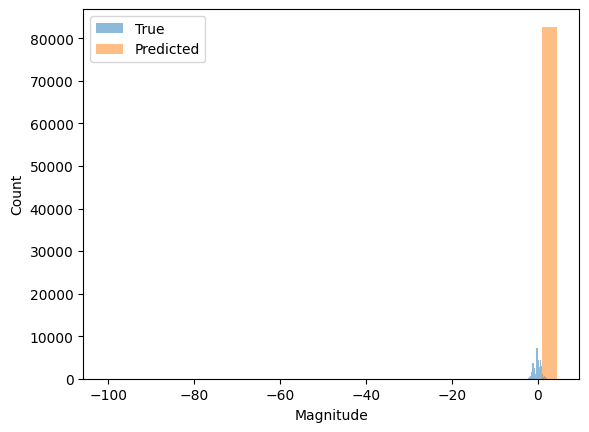

In [9]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

,Rows outside 0–6
true_magnitude,42814
predicted_magnitude,1


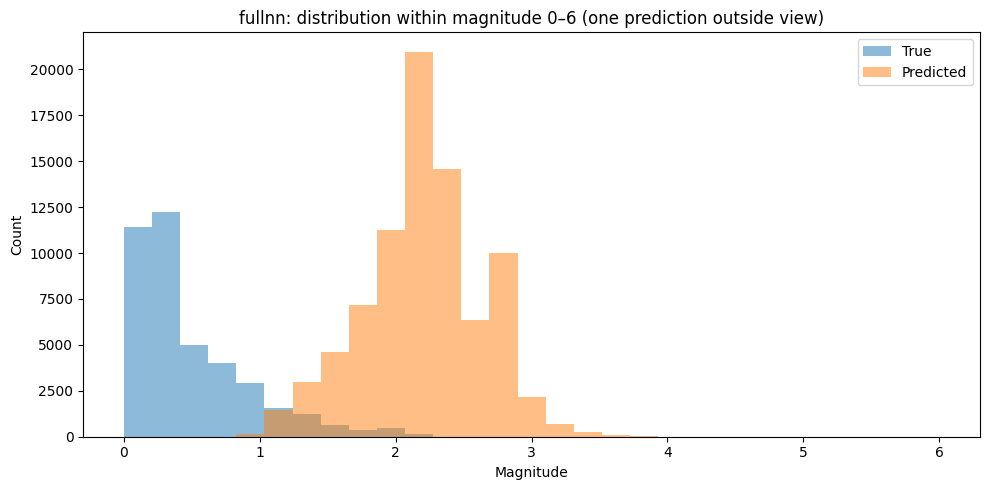

In [10]:
lower, upper = 0, 6
bins = np.linspace(lower, upper, 30)
outside = ((results < lower) | (results > upper)).sum()
display(outside.rename('Rows outside 0–6').to_frame())

plt.figure(figsize=(10, 5))
plt.hist(results['true_magnitude'], bins=bins, alpha=0.5, label='True')
plt.hist(results['predicted_magnitude'], bins=bins, alpha=0.5, label='Predicted')
plt.title('fullnn: distribution within magnitude 0–6 (one prediction outside view)')
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
print(results.describe())

       true_magnitude  predicted_magnitude
count    82769.000000         82769.000000
mean        -0.070569             2.202745
std          0.714146             0.558195
min         -2.188021          -100.632248
25%         -0.288021             1.955069
50%         -0.088021             2.224597
75%          0.311979             2.460469
max          2.211979             4.438688


In [12]:
results["error"] = (
    results["predicted_magnitude"]
    - results["true_magnitude"]
)

results["bin"] = pd.cut(
    results["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",34413,2.039144,2.054862
"(1, 2]",5068,1.435372,1.455711
"(2, 3]",474,0.896159,0.802708


In [13]:
mask = (results["true_magnitude"] >= 0) & (results["true_magnitude"] < 1)

mae_0_1 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_0_1)

2.0391436


In [14]:
mask = (results["true_magnitude"] >= 1) & (results["true_magnitude"] < 2)

mae_1_2 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_1_2 )

1.4363655


In [15]:
mask = (results["true_magnitude"] >= 2) & (results["true_magnitude"] < 3)

mae_2_3 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_2_3 )

0.90353465


In [16]:
mask = (results["true_magnitude"] >= 3) & (results["true_magnitude"] < 4)

mae_3_4 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_3_4 )

nan


In [17]:
mask = (results["true_magnitude"] >= 4) & (results["true_magnitude"] < 5)

mae_4_5 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_4_5 )

nan


In [18]:
mask = (results["true_magnitude"] >= 5) & (results["true_magnitude"] < 6)

mae_5_6 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_5_6 )

nan


In [19]:
maebins = [mae_0_1,mae_1_2,mae_2_3,mae_3_4,mae_4_5,mae_5_6]


In [20]:

mae_df = pd.DataFrame({
    "bin": ["0-1", "1-2", "2-3", "3-4", "4-5", "5-6"],
    "MAE": maebins
})

print(mae_df)

   bin       MAE
0  0-1  2.039144
1  1-2  1.436365
2  2-3  0.903535
3  3-4       NaN
4  4-5       NaN
5  5-6       NaN


In [21]:
results["error"] = (
    results["predicted_magnitude"] -
    results["true_magnitude"]
)
for low in range(6):
    mask = (
        (results["true_magnitude"] >= low) &
        (results["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results.loc[mask, "error"].abs().mean(),
        "bias =", results.loc[mask, "error"].mean()
    )

0-1 count = 34413 MAE = 2.0391436 bias = 2.0391436
1-2 count = 5068 MAE = 1.4363655 bias = 1.435372
2-3 count = 474 MAE = 0.90353465 bias = 0.89615947
3-4 count = 0 MAE = nan bias = nan
4-5 count = 0 MAE = nan bias = nan
5-6 count = 0 MAE = nan bias = nan


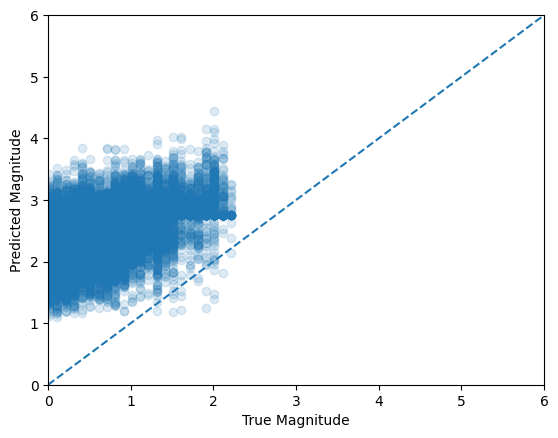

In [22]:
plt.scatter(
    results["true_magnitude"],
    results["predicted_magnitude"],
    alpha=0.15
)

plt.plot([0, 6], [0, 6], "--")

plt.xlabel("True Magnitude")
plt.ylabel("Predicted Magnitude")
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.show()

In [23]:
print(results.count())

true_magnitude         82769
predicted_magnitude    82769
error                  82769
bin                    39955
dtype: int64


In [24]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from fullmodeltrain.instancepipeline import get_data_loaders2
from fullmodeltrain.finalfulltrain import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path2 = PROJECT_ROOT / "fullmodeltrain" / "data" / "best_model_fullabovemeannn.pth"

checkpoint2 = torch.load(checkpoint_path2, map_location=device)
model2 = EarthquakeCNN().to(device)

model2.load_state_dict(checkpoint2["model_state_dict"])

model2.eval()




EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [25]:
all_predictions = []
all_targets = []

model2.eval()
TARGET_MEAN = 2.28802128052746
with torch.no_grad():
    for waveforms, magnitudes in test_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)

        # model predicts centered magnitude
        predictions = model2(waveforms).squeeze(-1)

        # convert BOTH back to actual magnitude
        
        predictions = predictions + TARGET_MEAN
        magnitudes = magnitudes + TARGET_MEAN

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

results2 = pd.DataFrame({
    "true_magnitude": all_targets,
    "predicted_magnitude": all_predictions
})

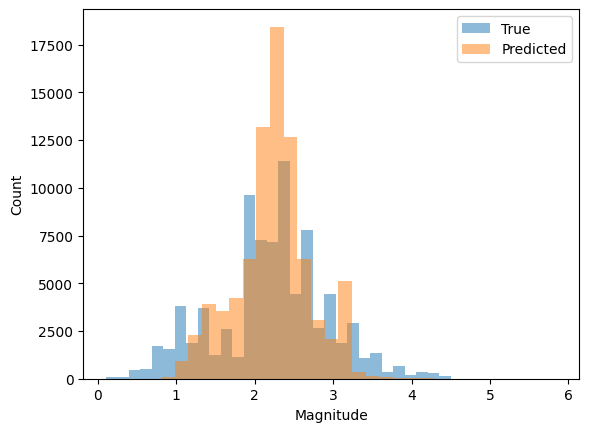

In [26]:
import matplotlib.pyplot as plt

plt.hist(results2["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results2["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [27]:
results2["error"] = (
    results2["predicted_magnitude"]
    - results2["true_magnitude"]
)

results2["bin"] = pd.cut(
    results2["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results2.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",6130,0.750864,0.694548
"(1, 2]",22281,0.314121,0.286545
"(2, 3]",45138,-0.084848,-0.066495
"(3, 4]",8407,-0.617025,-0.617393
"(4, 5]",813,-1.161139,-1.224416


In [28]:
results2["error"] = (
    results2["predicted_magnitude"] -
    results2["true_magnitude"]
)
for low in range(6):
    mask = (
        (results2["true_magnitude"] >= low) &
        (results2["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results2.loc[mask, "error"].abs().mean(),
        "bias =", results2.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 0.8103498 bias = 0.8101143
1-2 count = 15919 MAE = 0.45406088 bias = 0.41861212
2-3 count = 51082 MAE = 0.2635971 bias = -0.030939335
3-4 count = 10339 MAE = 0.5932389 bias = -0.57255834
4-5 count = 986 MAE = 1.149943 bias = -1.1385401
5-6 count = 0 MAE = nan bias = nan


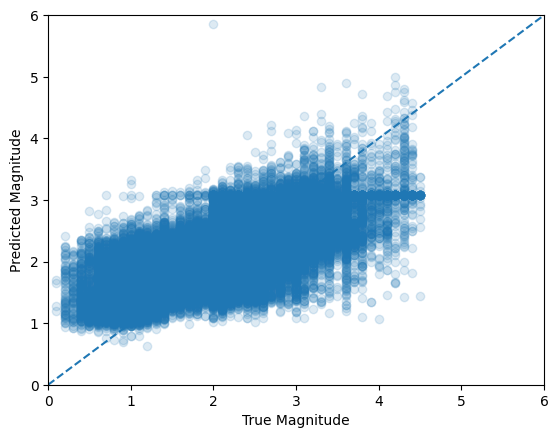

In [29]:
plt.scatter(
    results2["true_magnitude"],
    results2["predicted_magnitude"],
    alpha=0.15
)

plt.plot([0, 6], [0, 6], "--")

plt.xlabel("True Magnitude")
plt.ylabel("Predicted Magnitude")
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.show()